# GPT Training Pipeline




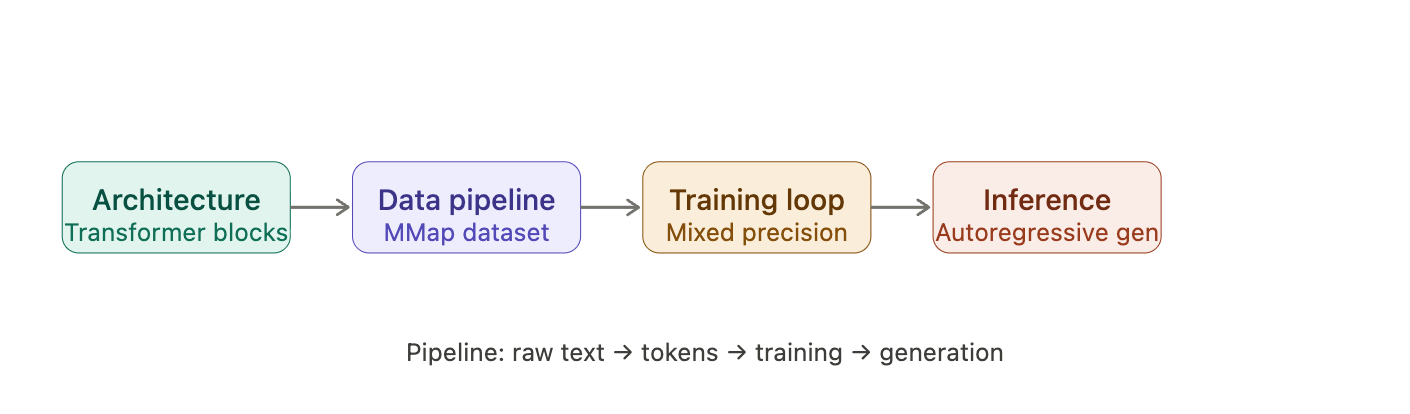

## 1. Architecture

### `LayerNorm`
Custom layer normalization. Normalizes each token's features independently (not across batch). Uses learnable `scale` (γ) and `shift` (β) params. `unbiased=False` uses N in denominator, matching PyTorch convention.

### `GELU`
Activation function used instead of ReLU. Smooth, non-zero for slightly negative inputs. Uses the fast **tanh approximation**.

### `FeedForward`
Two linear layers with GELU in between. Hidden dim is **4× the embedding dim** (e.g. 768 → 3072 → 768). Applied independently to each token position.

### `MultiHeadAttentionFast`
Causal multi-head self-attention. Projects input into Q, K, V then reshapes into per-head views via `.view()` + `.transpose()`. Uses `F.scaled_dot_product_attention` (Flash Attention) — fused kernel, ~3-4× faster than manual. `is_causal=True` applies the upper-triangular mask automatically.

### `GPTModel`
Full transformer. Sums **token embeddings** + **positional embeddings** at input. Stacks N transformer blocks, each with:
- Pre-LN residual: `x = x + dropout(attention(norm(x)))`
- Pre-LN residual: `x = x + dropout(ffn(norm(x)))`

Final `LayerNorm` → linear head projects to vocab logits.

---

## 2. Data Pipeline

### `MMapDataset`
Memory-maps a `.bin` file of `uint16` token IDs — streams from disk, no RAM crash on large datasets. Each sample is `(input, target)` where target = input shifted by 1 (next-token prediction). `stride` controls window overlap.

### `create_dummy_mmap_data`
Generates a fake `.bin` file of random token IDs for smoke-testing the pipeline.

---

## 3. Training Loop

### LR Schedule
- **Warmup** (first 20% of steps): LR ramps from 1% → 100% of peak. Stabilizes early training with random weights.
- **Cosine decay** (remaining 80%): smoothly reduces LR to `eta_min=1e-5`.

### Mixed Precision
- Forward pass runs in `bfloat16` (or `float16`) via `torch.autocast`. ~2-3× faster on GPU tensor cores.
- `GradScaler` scales the loss up before `backward()` to prevent float16 underflow, then unscales before the optimizer step.

### Gradient Clipping
`clip_grad_norm_(..., max_norm=1.0)` — caps the global gradient norm to prevent a bad batch from exploding the weights. **Must call `scaler.unscale_()` first** so clipping operates in float32 units.

### Step order
```
zero_grad → autocast forward → scaler.scale(loss).backward()
→ unscale_ → clip_grad_norm_ → scaler.step → scaler.update → scheduler.step
```

---

## 4. Inference

### `generate_text_simple`
Greedy autoregressive decoding loop:
1. Crop sequence to `context_size` (sliding window)
2. Forward pass with `torch.no_grad()`
3. Take logits at **last position only** → `(1, vocab_size)`
4. `argmax` → most probable next token
5. Append and repeat

Greedy = deterministic but repetitive. Real generation would use temperature / top-k / nucleus sampling.

---

## 5. Orchestrator

| Step | Detail |
|---|---|
| Config | 4-layer GPT-2 Small proportions (`emb_dim=768`, `n_heads=12`) |
| Data | Dummy `.bin` file → `MMapDataset` → `DataLoader` |
| Optimizer | `AdamW` with `lr=5e-4`, `weight_decay=0.1` |
| Compile | `torch.compile()` for ~30% speedup (Linux + PyTorch 2.0+ only) |
| Save | `torch.save(state_dict)` |
| Load | `mmap=True` streams weights from disk; `assign=True` avoids double RAM allocation; `weights_only=True` for security |
| Generate | Encode prompt with `tiktoken` → `generate_text_simple` → decode back to text |

In [8]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tiktoken  # OpenAI's fast BPE tokenizer — same vocab as GPT-2

# =============================================================================
# SECTION 1: MODEL ARCHITECTURE
# =============================================================================
# We build a GPT-2-style decoder-only transformer from scratch.
# The model is composed of stacked transformer blocks, each containing:
#   - Multi-head causal self-attention
#   - A feed-forward network (MLP)
#   - Layer normalization + residual connections


class LayerNorm(nn.Module):
    """
    Custom Layer Normalization.

    Unlike BatchNorm (which normalizes across the batch dimension),
    LayerNorm normalizes each sample's features independently.
    This is preferred in NLP because sequence lengths vary,
    making batch statistics unreliable.

    Formula: scale * (x - mean) / sqrt(var + eps) + shift
    - eps: small constant prevents division by zero
    - scale & shift: learnable parameters to let the model
      undo normalization if needed
    """
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # gamma (γ)
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # beta (β)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        # unbiased=False uses N (not N-1) in denominator — matches PyTorch's convention
        return self.scale * ((x - mean) / torch.sqrt(var + self.eps)) + self.shift


class GELU(nn.Module):
    """
    Gaussian Error Linear Unit activation function.

    GELU is the standard activation in GPT-style models.
    It differs from ReLU by being smooth and non-zero for slightly
    negative inputs, which tends to improve training dynamics.

    This is the tanh approximation (slightly faster than the exact version):
      GELU(x) ≈ 0.5 * x * (1 + tanh(√(2/π) * (x + 0.044715 * x³)))
    """
    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN).

    Applied independently to each token position after attention.
    The hidden dimension is 4× the embedding dimension — this is the
    standard GPT-2 ratio, giving the model expressiveness to store
    factual knowledge.

    Architecture: Linear → GELU → Linear
    Input/Output: (batch, seq_len, emb_dim) → (batch, seq_len, emb_dim)
    """
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # expand: e.g. 768 → 3072
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # project back: 3072 → 768
        )

    def forward(self, x):
        return self.layers(x)


class MultiHeadAttentionFast(nn.Module):
    """
    Multi-Head Causal Self-Attention using PyTorch's fused kernel.

    'Causal' means each token can only attend to previous tokens
    (not future ones), which is required for autoregressive generation.

    Key ideas:
    - Queries (Q): what this token is looking for
    - Keys   (K): what each token offers to be found
    - Values (V): the actual content to aggregate
    - Attention score = softmax(Q·Kᵀ / √d_head) · V

    Multi-head: run H independent attention operations in parallel,
    each focusing on different relationship types (syntax, coreference, etc.)
    Then concatenate all heads and project back to emb_dim.

    Using F.scaled_dot_product_attention (Flash Attention) is ~3-4× faster
    than a manual implementation because it fuses the attention computation
    into a single GPU kernel, avoiding large intermediate matrices.
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # each head's feature size

        # Separate linear projections for Q, K, V (no bias — matches GPT-2)
        self.W_query = nn.Linear(d_in, d_out, bias=True)
        self.W_key   = nn.Linear(d_in, d_out, bias=True)
        self.W_value = nn.Linear(d_in, d_out, bias=True)

        # Final linear projection after concatenating all heads
        self.out_proj = nn.Linear(d_out, d_out, bias=True)
        self.dropout_rate = dropout

    def forward(self, x):
        b, num_tokens, _ = x.shape

        # Project input to Q, K, V then reshape into per-head views.
        # view splits emb_dim into (num_heads, head_dim).
        # transpose(1,2) moves head dim before seq dim for batched matmul:
        #   (b, num_tokens, num_heads, head_dim) → (b, num_heads, num_tokens, head_dim)
        keys    = self.W_key(x)  .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Fused Flash Attention kernel. is_causal=True automatically builds
        # the upper-triangular mask so token i cannot attend to token j > i.
        context_vec = F.scaled_dot_product_attention(
            queries, keys, values,
            attn_mask=None,
            dropout_p=self.dropout_rate if self.training else 0.0,
            is_causal=True  # enforces causal (left-to-right) masking
        )

        # Reassemble heads: (b, num_heads, num_tokens, head_dim)
        #                 → (b, num_tokens, num_heads * head_dim)
        #                 = (b, num_tokens, emb_dim)
        context_vec = context_vec.transpose(1, 2).contiguous().view(b, num_tokens, -1)
        return self.out_proj(context_vec)


class GPTModel(nn.Module):
    """
    Full GPT-2-style decoder-only transformer.

    Input:  token IDs  (batch, seq_len) — integers indexing into vocabulary
    Output: logits     (batch, seq_len, vocab_size) — raw scores over vocabulary

    Two types of embeddings are summed at the start:
    - Token embeddings:    look up a vector for each token ID
    - Positional embeddings: look up a vector for each position (0, 1, 2, ...)
      This gives the model awareness of token order since attention is
      inherently permutation-invariant.

    Each transformer block uses a Pre-LN (normalize before attention/FFN)
    arrangement, which is more stable than Post-LN during training.

    Residual connections (x = x + sublayer(x)) let gradients flow
    directly to early layers, solving the vanishing gradient problem.
    """
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb  = nn.Embedding(cfg["vocab_size"],    cfg["emb_dim"])
        self.pos_emb  = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of n_layers transformer blocks
        self.trf_blocks = nn.ModuleList([
            nn.ModuleDict({
                "att":   MultiHeadAttentionFast(
                            cfg["emb_dim"], cfg["emb_dim"],
                            cfg["context_length"], cfg["drop_rate"], cfg["n_heads"]
                         ),
                "ff":    FeedForward(cfg),
                "norm1": LayerNorm(cfg["emb_dim"]),  # applied before attention
                "norm2": LayerNorm(cfg["emb_dim"]),  # applied before FFN
                "drop":  nn.Dropout(cfg["drop_rate"])
            }) for _ in range(cfg["n_layers"])
        ])

        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Language modeling head: project hidden states to vocab logits.
        # No bias — standard practice for tied embedding / output projection.
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        seq_len = in_idx.shape[1]

        # Build positional indices [0, 1, ..., seq_len-1] on the correct device
        pos_indices = torch.arange(seq_len, device=in_idx.device)

        # Combine token + position information
        x = self.tok_emb(in_idx) + self.pos_emb(pos_indices)
        x = self.drop_emb(x)  # dropout on embeddings acts as input regularization

        # Pass through each transformer block
        for block in self.trf_blocks:
            # Pre-LN residual: normalize → transform → add back to input
            x = x + block["drop"](block["att"](block["norm1"](x)))  # attention sub-layer
            x = x + block["drop"](block["ff"] (block["norm2"](x)))  # FFN sub-layer

        # Final layer norm before projecting to vocabulary
        return self.out_head(self.final_norm(x))


# =============================================================================
# SECTION 2: DATA PIPELINE
# =============================================================================
# For large datasets (billions of tokens), loading everything into RAM
# would crash. Memory-mapped files let us stream data directly from
# disk — the OS loads only the pages we're actually reading.


class MMapDataset(Dataset):
    """
    Memory-mapped token dataset for large-scale training.

    The binary file stores raw uint16 token IDs (0–65535), which covers
    GPT-2's 50,257-token vocabulary while using only 2 bytes per token
    (vs 4 bytes for int32).

    Each sample is a (input, target) pair of length `max_length` where
    target is input shifted by one position — this is the standard
    next-token prediction objective (CLM).

    stride < max_length creates overlapping windows for more training signal.
    stride = max_length gives non-overlapping chunks (faster, less data).
    """
    def __init__(self, bin_file_path, max_length, stride):
        # mode='r' → read-only memory map; OS handles paging automatically
        self.data = np.memmap(bin_file_path, dtype=np.uint16, mode='r')
        self.max_length = max_length
        self.stride = stride

    def __len__(self):
        # Number of valid starting positions given stride
        return (len(self.data) - self.max_length) // self.stride

    def __getitem__(self, idx):
        start_idx = idx * self.stride
        # Fetch max_length + 1 tokens: first N are input, last N are target
        chunk = self.data[start_idx : start_idx + self.max_length + 1]

        # input:  tokens[0..N-1]  — what the model sees
        # target: tokens[1..N]    — what the model must predict at each step
        return (
            torch.tensor(chunk[:-1], dtype=torch.long),
            torch.tensor(chunk[1:],  dtype=torch.long)
        )


def create_dummy_mmap_data(filename="train_data.bin", num_tokens=100_000):
    """
    Generate a fake training file of random token IDs for testing.
    In real training, this would be replaced with tokenized text corpora.
    """
    dummy_data = np.random.randint(0, 50257, size=num_tokens, dtype=np.uint16)
    with open(filename, "wb") as f:
        f.write(dummy_data.tobytes())


# =============================================================================
# SECTION 3: PRODUCTION TRAINING LOOP
# =============================================================================
# This loop combines four production techniques:
#   1. LR warmup + cosine annealing schedule
#   2. Gradient clipping (prevents exploding gradients)
#   3. Mixed precision (bfloat16/float16 for 2-3× speedup)
#   4. GradScaler (prevents underflow when using float16)


def train_model_production(model, train_loader, optimizer, device, num_epochs):
    total_steps = len(train_loader) * num_epochs

    # ------------------------------------------------------------------
    # Learning Rate Schedule: Warmup → Cosine Decay
    #
    # Why warm up? At the start, random weights produce large, noisy
    # gradients. A tiny LR for the first ~20% of steps lets the model
    # "find its footing" before ramping up to full speed.
    #
    # Why cosine decay? Gently reducing LR toward the end prevents
    # overshooting the loss minimum. Cosine is smoother than step decay.
    # ------------------------------------------------------------------
    warmup_steps  = max(1, total_steps // 5)           # first 20% of steps
    cosine_steps  = total_steps - warmup_steps

    warmup  = torch.optim.lr_scheduler.LinearLR(
                  optimizer, start_factor=0.01,         # start at 1% of peak LR
                  total_iters=warmup_steps
              )
    cosine  = torch.optim.lr_scheduler.CosineAnnealingLR(
                  optimizer, T_max=cosine_steps,
                  eta_min=1e-5                          # floor LR at 0.00001
              )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
                    optimizer,
                    schedulers=[warmup, cosine],
                    milestones=[warmup_steps]           # switch at end of warmup
                )

    # ------------------------------------------------------------------
    # Mixed Precision Training
    #
    # Most GPU tensor cores run 2-3× faster in 16-bit math.
    # bfloat16 (if supported) is preferred over float16 because it has
    # the same exponent range as float32 — reducing the risk of overflow.
    # The GradScaler compensates for float16's limited range during backprop
    # by scaling the loss up before backward() and unscaling before the
    # optimizer step.
    # ------------------------------------------------------------------
    scaler  = torch.amp.GradScaler(device.type)
    ptdtype = (
        torch.bfloat16
        if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
        else torch.float16
    )
    print(f"Using mixed precision: {ptdtype}")

    model.train()
    global_step = 0

    for epoch in range(num_epochs):
        for batch_idx, (input_batch, target_batch) in enumerate(train_loader):
            input_batch  = input_batch.to(device)
            target_batch = target_batch.to(device)

            optimizer.zero_grad()  # clear gradients from previous step

            # Forward pass in 16-bit math (faster matrix multiplications)
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                logits = model(input_batch)
                # flatten (batch, seq_len, vocab) → (batch*seq_len, vocab) for cross_entropy
                loss   = F.cross_entropy(
                             logits.flatten(0, 1),      # predictions
                             target_batch.flatten()     # ground-truth token IDs
                         )

            # Backward pass: scale loss to avoid float16 underflow,
            # then unscale before clipping so the norm is in float32 units
            scaler.scale(loss).backward()

            # Gradient clipping: cap the global gradient norm at 1.0
            # This prevents a single bad batch from destabilizing training
            scaler.unscale_(optimizer)  # must unscale before clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)   # apply gradients (skipped if inf/NaN detected)
            scaler.update()          # adjust scaler factor for next step
            scheduler.step()         # advance LR schedule

            global_step += 1
            if global_step % 10 == 0:
                print(
                    f"Epoch {epoch+1} | Step {global_step:04d} "
                    f"| Loss: {loss.item():.4f} "
                    f"| LR: {optimizer.param_groups[0]['lr']:.6f}"
                )


# =============================================================================
# SECTION 4: TEXT GENERATION (INFERENCE)
# =============================================================================

def generate_text_simple(model, idx, max_new_tokens, context_size, temperature=1.0, top_k=None):
    """
    Autoregressive greedy decoding.

    How it works:
      1. Feed the current token sequence into the model
      2. Take the logits for the LAST position (next-token prediction)
      3. Pick the token with the highest score (greedy)
      4. Append it and repeat

    This is the simplest decoding strategy. For better output quality,
    you would use temperature scaling, top-k sampling, or nucleus (top-p)
    sampling instead of pure argmax.

    Args:
        model:          trained GPTModel
        idx:            starting token IDs, shape (1, prompt_len)
        max_new_tokens: how many tokens to generate
        context_size:   model's maximum sequence length (must not exceed this)
    """
    model.eval()  # disables dropout for deterministic output

    for _ in range(max_new_tokens):
        # Crop to the model's context window if the sequence has grown too long
        idx_cond = idx[:, -context_size:]

        # No gradient needed during inference — saves memory and compute
        with torch.no_grad():
            logits = model(idx_cond)  # (1, seq_len, vocab_size)

        # Focus only on the prediction for the very next token
        logits = logits[:, -1, :]      # (1, vocab_size)

        # --- NEW: Top-K Filtering ---
        if top_k is not None:
            # Find the top K values and their indices
            top_logits, _ = torch.topk(logits, top_k)
            # Find the lowest value in that top K group
            min_val = top_logits[:, -1]
            # Replace anything lower than that minimum value with -infinity
            logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

        # --- NEW: Temperature Scaling & Sampling ---
        if temperature > 0.0:
            # Scale the logits by temperature
            logits = logits / temperature
            # Convert logits into probabilities that sum to 1.0
            probs = torch.softmax(logits, dim=-1)
            # Randomly sample 1 token based on the probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # If temperature is 0, fallback to pure greedy decoding (argmax)
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Grow the sequence and loop
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# =============================================================================
# SECTION 5: MAIN ORCHESTRATOR
# =============================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device.type.upper()}")

    # --- Model configuration (GPT-2 Small proportions, 4 layers for quick testing) ---
    CFG = {
        "vocab_size":      50257,  # GPT-2 BPE vocabulary size
        "context_length":  256,    # max tokens in one forward pass
        "emb_dim":         768,    # embedding / hidden dimension
        "n_heads":         12,     # attention heads (head_dim = 768/12 = 64)
        "n_layers":        4,      # transformer blocks (GPT-2 Small uses 12)
        "drop_rate":       0.1,    # 10% dropout on embeddings, attention, FFN
    }

    # --- Data setup ---
    create_dummy_mmap_data("train_data.bin", num_tokens=50_000)
    dataset      = MMapDataset("train_data.bin", max_length=CFG["context_length"], stride=CFG["context_length"])
    train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

    # --- Model + optimizer ---
    model     = GPTModel(CFG).to(device)
    optimizer = torch.optim.AdamW(
                    model.parameters(),
                    lr=5e-4,           # peak learning rate (scheduler will modulate this)
                    weight_decay=0.1   # L2 regularization on weights to prevent overfitting
                )

    # torch.compile() uses Triton to JIT-compile model kernels for ~30% speedup.
    # Only works on Linux/WSL with PyTorch 2.0+; skipped on Windows (os.name == 'nt').
    if hasattr(torch, "compile") and os.name != "nt":
        print("Compiling model with torch.compile()...")
        model = torch.compile(model)

    # --- Training ---
    print("\n--- Starting training ---")
    train_model_production(model, train_loader, optimizer, device, num_epochs=2)

    # --- Save / load with memory-efficient mmap ---
    # mmap=True tells PyTorch to memory-map the .pth file instead of
    # reading all weights into RAM at once — critical for large models.
    # assign=True copies tensors directly into the model without allocating
    # a second copy, halving peak memory usage during loading.
    print("\n--- Saving and reloading weights ---")
    torch.save(model.state_dict(), "model_weights.pth")
    state_dict = torch.load(
                     "model_weights.pth",
                     map_location=device,
                     weights_only=True,  # security: don't execute arbitrary pickle code
                     mmap=True           # stream weights from disk
                 )
    model.load_state_dict(state_dict, assign=True)
    print("Weights loaded.")

    # --- Inference ---
    print("\n--- Generating text ---")
    tokenizer     = tiktoken.get_encoding("gpt2")
    prompt        = "The secret to training large language models is"
    encoded       = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)

    generated_ids = generate_text_simple(
                        model=model,
                        idx=encoded,
                        max_new_tokens=30,
                        context_size=CFG["context_length"]
                    )

    decoded = tokenizer.decode(generated_ids.squeeze(0).tolist())
    print(f"\nOutput:\n{decoded}")
    print("\n(Trained on random dummy data — output will be gibberish. Load real GPT-2 weights for coherent text.)")

Device: CUDA
Compiling model with torch.compile()...

--- Starting training ---
Using mixed precision: torch.bfloat16


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


Epoch 1 | Step 0010 | Loss: 11.0099 | LR: 0.000500
Epoch 1 | Step 0020 | Loss: 11.0087 | LR: 0.000428
Epoch 2 | Step 0030 | Loss: 9.8500 | LR: 0.000255
Epoch 2 | Step 0040 | Loss: 9.4534 | LR: 0.000082
Epoch 2 | Step 0050 | Loss: 9.2306 | LR: 0.000010

--- Saving and reloading weights ---
Weights loaded.

--- Generating text ---

Output:
The secret to training large language models isvertisementsZipscale Jindal是 fs disappoint CITY postings.''. Expend invariablyWrð� negligence473 Manires Pumpkin Chrys nostalgia STORY Cru succeed prostitution Miche spansADE voted

(Trained on random dummy data — output will be gibberish. Load real GPT-2 weights for coherent text.)


# Pretrained GPT 2 Weight Loading

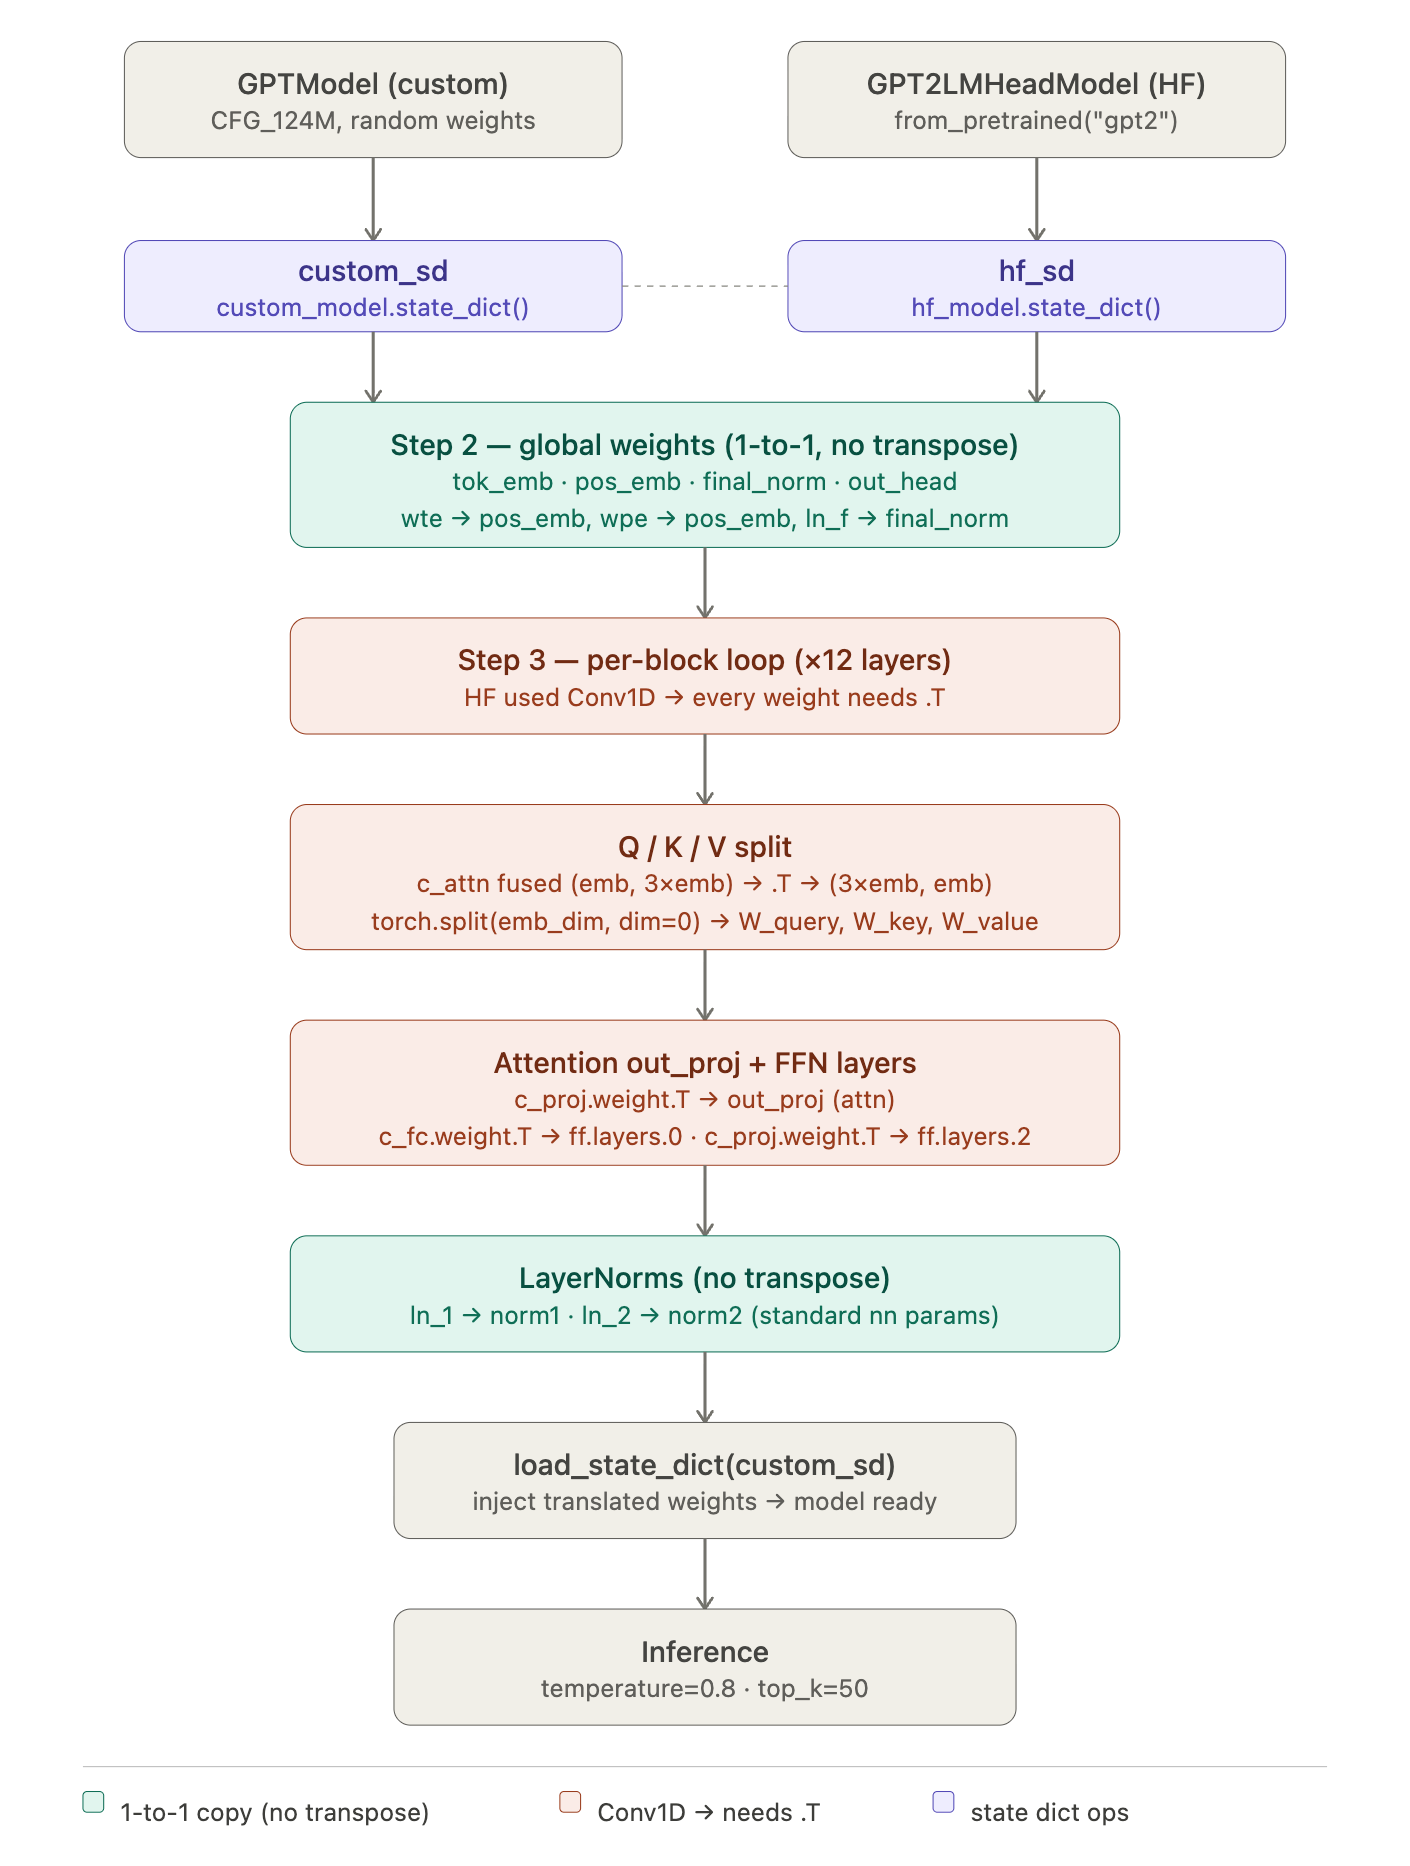

## The Core Problem
HF's `GPT2LMHeadModel` and our `GPTModel` are architecturally identical but differ in two ways:
1. **Key names** — e.g. HF's `transformer.wte.weight` vs our `tok_emb.weight`
2. **Tensor layout** — HF used `Conv1D` internally, which stores weights as `(in, out)`. Our `nn.Linear` expects `(out, in)`. Fix: call `.T` on every affected weight. **Biases are 1D — never need `.T`.**

---

## `load_weights_into_custom_gpt()`

### Step 1 — Get state dicts
`state_dict()` returns a `{name: tensor}` dict. We edit `custom_sd` in-place and write it back at the end with `load_state_dict()`.

### Step 2 — Global weights (1-to-1, no transpose)
| Ours | HF |
|---|---|
| `tok_emb.weight` | `transformer.wte.weight` |
| `pos_emb.weight` | `transformer.wpe.weight` |
| `final_norm.scale/shift` | `transformer.ln_f.weight/bias` |
| `out_head.weight` | `lm_head.weight` |

### Step 3 — Per-block weights (loop over all 12 layers)

**Q, K, V attention weights — the tricky part:**
HF fuses all three projections into one matrix `c_attn` of shape `(emb_dim, 3×emb_dim)`. After `.T` → `(3×emb_dim, emb_dim)`. Use `torch.split(..., emb_dim, dim=0)` to unpack into three `(emb_dim, emb_dim)` chunks and inject into our separate `W_query`, `W_key`, `W_value` linears.

**Everything else needs `.T` (Conv1D layers):**
- `attn.c_proj` → `att.out_proj`
- `mlp.c_fc` → `ff.layers.0` (expand: emb_dim → 4×emb_dim)
- `mlp.c_proj` → `ff.layers.2` (contract: 4×emb_dim → emb_dim)

**LayerNorms — no transpose:**
- `ln_1` → `norm1` (before attention)
- `ln_2` → `norm2` (before FFN)

### Step 4 — Write back
`custom_model.load_state_dict(custom_sd)` — model now has real GPT-2 intelligence.

---

## Inference (bottom of script)
Same `generate_text_simple()` as before, but with two extra args:
- `temperature=0.8` — scales logits before sampling; `<1.0` = more focused, `>1.0` = more random
- `top_k=50` — zero out all but the top 50 tokens before sampling, preventing low-probability garbage

`drop_rate=0.0` in `CFG_124M` because dropout is only for training, not inference.

In [13]:
import torch
import numpy as np
from transformers import GPT2LMHeadModel

def load_weights_into_custom_gpt(custom_model, hf_model):
    """
    Transplants official GPT-2 weights from Hugging Face into our custom model.

    WHY we need this:
      Hugging Face's GPT2LMHeadModel and our GPTModel are architecturally
      identical, but their weight dictionaries use different key names AND
      different tensor layouts (HF used Conv1D internally, which stores
      weight matrices transposed relative to nn.Linear's convention).
      This function bridges that mismatch so we can use real pre-trained
      intelligence instead of random weights.

    The two key differences to handle:
      1. Name mismatch  — e.g. HF's "transformer.wte.weight" vs our "tok_emb.weight"
      2. Transpose mismatch — HF Conv1D stores (in_features, out_features),
                              nn.Linear expects (out_features, in_features), so
                              we call .T on every weight that came from a Conv1D layer.
    """

    # Step 1: Get both models' weight dictionaries.
    # state_dict() returns an OrderedDict of {param_name: tensor}.
    # We get custom_sd as a mutable reference — edits to it will be
    # written back into the model via load_state_dict() at the end.
    custom_sd = custom_model.state_dict()
    hf_sd     = hf_model.state_dict()

    # -------------------------------------------------------------------------
    # Step 2: Translate the "global" weights (embeddings + final norm + LM head)
    #
    # These are 1-to-1 mappings — same shape, just different key names.
    # No transpose needed because these layers weren't Conv1D in HF.
    # -------------------------------------------------------------------------
    custom_sd["tok_emb.weight"]    = hf_sd["transformer.wte.weight"]   # token embeddings
    custom_sd["pos_emb.weight"]    = hf_sd["transformer.wpe.weight"]   # positional embeddings
    custom_sd["final_norm.scale"]  = hf_sd["transformer.ln_f.weight"]  # final LayerNorm γ
    custom_sd["final_norm.shift"]  = hf_sd["transformer.ln_f.bias"]    # final LayerNorm β
    custom_sd["out_head.weight"]   = hf_sd["lm_head.weight"]           # vocab projection head

    # -------------------------------------------------------------------------
    # Step 3: Translate per-block weights (attention + FFN + LayerNorms)
    # -------------------------------------------------------------------------
    for i in range(len(custom_model.trf_blocks)):

        # --- Attention Q, K, V weights ---
        #
        # In Hugging Face GPT-2, all three attention projections (Query, Key,
        # Value) are fused into ONE matrix called c_attn, with shape:
        #   (emb_dim, 3 * emb_dim)   ← stored as Conv1D, so we .T it first
        #
        # After transposing → (3 * emb_dim, emb_dim)
        # We then split along dim=0 into three equal (emb_dim, emb_dim) chunks.
        # Our model has three separate W_query / W_key / W_value nn.Linear layers,
        # so we inject each chunk individually.
        qkv_weights = hf_sd[f"transformer.h.{i}.attn.c_attn.weight"].T  # .T fixes Conv1D layout
        qkv_biases  = hf_sd[f"transformer.h.{i}.attn.c_attn.bias"]      # biases are 1D — no transpose needed

        emb_dim = custom_model.trf_blocks[i]["att"].W_query.weight.shape[1]

        # Split: [Q | K | V] along the first dimension
        q_w, k_w, v_w = torch.split(qkv_weights, emb_dim, dim=0)
        q_b, k_b, v_b = torch.split(qkv_biases,  emb_dim, dim=0)

        custom_sd[f"trf_blocks.{i}.att.W_query.weight"] = q_w
        custom_sd[f"trf_blocks.{i}.att.W_query.bias"]   = q_b
        custom_sd[f"trf_blocks.{i}.att.W_key.weight"]   = k_w
        custom_sd[f"trf_blocks.{i}.att.W_key.bias"]     = k_b
        custom_sd[f"trf_blocks.{i}.att.W_value.weight"] = v_w
        custom_sd[f"trf_blocks.{i}.att.W_value.bias"]   = v_b

        # --- Attention output projection ---
        # c_proj is also Conv1D → needs .T
        custom_sd[f"trf_blocks.{i}.att.out_proj.weight"] = hf_sd[f"transformer.h.{i}.attn.c_proj.weight"].T
        custom_sd[f"trf_blocks.{i}.att.out_proj.bias"]   = hf_sd[f"transformer.h.{i}.attn.c_proj.bias"]

        # --- Feed-forward network ---
        # Both linear layers in the MLP were Conv1D → both need .T
        # layers.0 = first linear (expand: emb_dim → 4*emb_dim)
        # layers.2 = second linear (contract: 4*emb_dim → emb_dim)
        # (layers.1 is GELU — no weights)
        custom_sd[f"trf_blocks.{i}.ff.layers.0.weight"] = hf_sd[f"transformer.h.{i}.mlp.c_fc.weight"].T
        custom_sd[f"trf_blocks.{i}.ff.layers.0.bias"]   = hf_sd[f"transformer.h.{i}.mlp.c_fc.bias"]
        custom_sd[f"trf_blocks.{i}.ff.layers.2.weight"] = hf_sd[f"transformer.h.{i}.mlp.c_proj.weight"].T
        custom_sd[f"trf_blocks.{i}.ff.layers.2.bias"]   = hf_sd[f"transformer.h.{i}.mlp.c_proj.bias"]

        # --- LayerNorms (no transpose — standard nn.LayerNorm convention) ---
        # norm1 runs before attention, norm2 runs before FFN (Pre-LN architecture)
        custom_sd[f"trf_blocks.{i}.norm1.scale"] = hf_sd[f"transformer.h.{i}.ln_1.weight"]
        custom_sd[f"trf_blocks.{i}.norm1.shift"]  = hf_sd[f"transformer.h.{i}.ln_1.bias"]
        custom_sd[f"trf_blocks.{i}.norm2.scale"] = hf_sd[f"transformer.h.{i}.ln_2.weight"]
        custom_sd[f"trf_blocks.{i}.norm2.shift"]  = hf_sd[f"transformer.h.{i}.ln_2.bias"]

    # Step 4: Write the fully-translated dictionary back into our model.
    # After this call, custom_model's parameters ARE the GPT-2 weights —
    # it will generate coherent English just like the official model.
    custom_model.load_state_dict(custom_sd)
    print("Pre-trained weights successfully loaded into custom architecture!")
    custom_model.to(device)  # note: was `my_model.to(device)` — likely a typo in original


# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":

    # GPT-2 124M ("Small") configuration — must exactly match the HF checkpoint
    # drop_rate=0.0 because we're doing inference, not training
    CFG_124M = {
        "vocab_size":     50257,
        "context_length": 1024,
        "emb_dim":        768,
        "n_heads":        12,
        "n_layers":       12,
        "drop_rate":      0.0
    }

    print("Building custom GPT model...")
    my_model = GPTModel(CFG_124M)

    print("Downloading official GPT-2 (124M) weights from Hugging Face...")
    hf_model = GPT2LMHeadModel.from_pretrained("gpt2")

    # Translate and inject all weights
    load_weights_into_custom_gpt(my_model, hf_model)
    # my_model is now fully loaded with real GPT-2 intelligence

    # --- Inference ---
    # Uses generate_text_simple() from the training script, but now with
    # temperature and top_k for better output than pure greedy decoding:
    #   temperature > 1.0 → more random, temperature < 1.0 → more focused
    #   top_k=50 → sample only from the 50 most likely next tokens,
    #              preventing the model from ever picking low-probability garbage
    print("\n--- Generating text ---")
    tokenizer = tiktoken.get_encoding("gpt2")
    prompt    = "The sun rises in the east "
    encoded   = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)

    generated_ids = generate_text_simple(
        model=my_model,
        idx=encoded,
        max_new_tokens=40,
        context_size=CFG_124M["context_length"],
        temperature=0.8,  # slight creativity without going off-rails
        top_k=50          # vocabulary truncation before sampling
    )

    decoded = tokenizer.decode(generated_ids.squeeze(0).tolist())
    print(f"\nOutput:\n{decoded}")

Building custom GPT model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-trained weights successfully loaded into custom architecture!

--- Generating text ---

Output:
The sun rises in the east  (left). The first moon rises in the west. The second moon rises in the east  (right). The blue moon rises in the west, but there are many more moon, but


# HParam Tuning

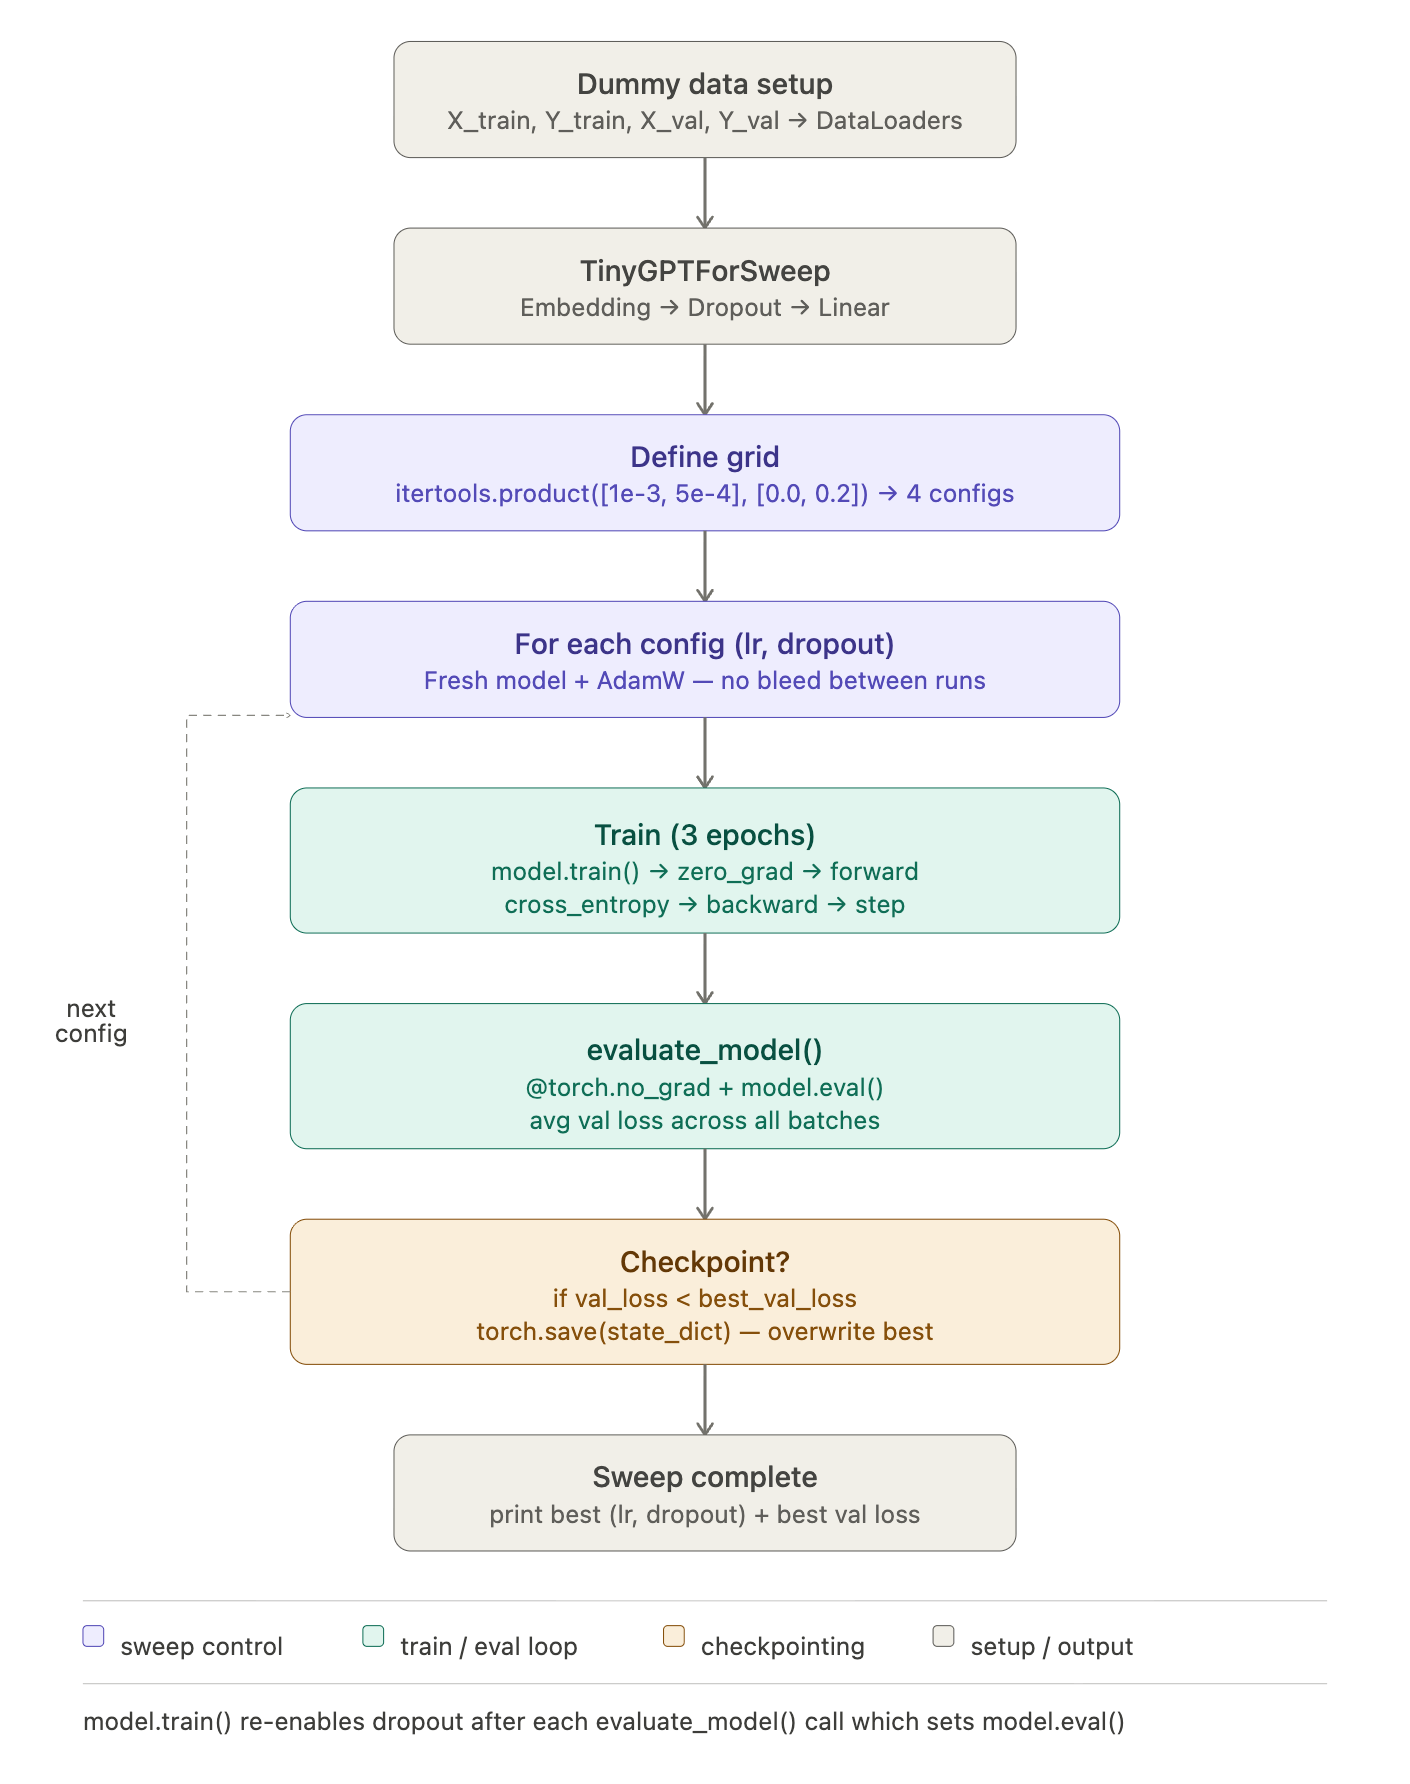

## The Core Idea
Exhaustively try every combination of hyperparameters, train a model for each, evaluate on held-out validation data, and save the best weights. Simple but effective when the search space is small.

---

## Section 1 — Dummy Data & Model

Random token IDs simulate a real dataset so the sweep runs instantly. `Y_train` would normally be `X_train` shifted by one position (next-token prediction) but random targets are fine here since we only care about **relative** loss comparisons between configs.

`TinyGPTForSweep`: just `Embedding → Dropout → Linear`. Not a real transformer — exists purely to demonstrate the sweep mechanics. `drop_rate` is a constructor arg so each config gets the correct dropout baked in from the start.

---

## Section 2 — `evaluate_model()`

Two critical decorators/calls:
- `@torch.no_grad()` — disables gradient graph construction, saves memory, ~2× faster
- `model.eval()` — disables Dropout so evaluation is **deterministic**

Without `model.eval()`, two identical eval runs would give different losses. Returns **average loss per batch** across the full validation set.

---

## Section 3 — `run_hyperparameter_sweep()`

### Grid definition
```python
itertools.product([1e-3, 5e-4], [0.0, 0.2])
# → (1e-3, 0.0), (1e-3, 0.2), (5e-4, 0.0), (5e-4, 0.2)
```

### Per-config loop
1. **Fresh model + optimizer every time** — reusing would bleed weights/momentum from previous config, making comparison meaningless
2. Train for 3 quick epochs
3. Call `evaluate_model()` → get validation loss
4. If best so far → `torch.save(model.state_dict(), path)`

### Checkpointing rule
Only saves when a new best is found — avoids unnecessary writes and guarantees the file always holds the single best model from the entire sweep.

---

## Key Reminders
| Thing | Why it matters |
|---|---|
| `model.train()` inside loop | Re-enables Dropout after `evaluate_model()` set it to eval |
| `loss.item()` | Pulls scalar off GPU into Python float for accumulation |
| `shuffle=False` on val loader | Order irrelevant for eval; keeps results reproducible |
| Grid search vs alternatives | Fine for 2×2=4 configs; use Optuna/random search for larger spaces |

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import itertools  # standard library — generates cartesian products of parameter lists

# =============================================================================
# SECTION 1: DUMMY DATA & MINIMAL MODEL
# =============================================================================
# Real training would load tokenized text from disk (e.g. MMapDataset).
# Here we use random integers to simulate token IDs so the sweep logic
# runs instantly without needing a real dataset or full GPT architecture.

vocab_size = 1000
seq_len    = 32

# 100 training samples, 20 validation samples, each of length 32
# Y is the target (next-token labels) — in real training this would be
# X shifted by one position, but random targets are fine for sweep testing
X_train = torch.randint(0, vocab_size, (100, seq_len))
Y_train = torch.randint(0, vocab_size, (100, seq_len))
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=16, shuffle=True)

X_val = torch.randint(0, vocab_size, (20, seq_len))
Y_val = torch.randint(0, vocab_size, (20, seq_len))
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=16, shuffle=False)
# shuffle=False on val — order doesn't matter, and reproducibility is nice


class TinyGPTForSweep(nn.Module):
    """
    Minimal 3-layer network just to demonstrate the sweep loop mechanics.
    Not a real transformer — just Embedding → Dropout → Linear.

    Accepts `drop_rate` as a constructor arg so each sweep config
    gets a freshly initialized model with the correct dropout baked in.
    """
    def __init__(self, vocab_size, emb_dim, drop_rate):
        super().__init__()
        self.emb    = nn.Embedding(vocab_size, emb_dim)  # token ID → dense vector
        self.drop   = nn.Dropout(drop_rate)               # regularization
        self.linear = nn.Linear(emb_dim, vocab_size)      # project back to vocab logits

    def forward(self, x):
        # x: (batch, seq_len) → logits: (batch, seq_len, vocab_size)
        return self.linear(self.drop(self.emb(x)))


# =============================================================================
# SECTION 2: EVALUATION FUNCTION
# =============================================================================

@torch.no_grad()  # disables gradient computation — no backward graph built,
                  # saves memory and runs ~2× faster during eval
def evaluate_model(model, val_loader, device):
    """
    Computes average cross-entropy loss over the entire validation set.

    Called AFTER training each sweep config. The validation loss is our
    single objective metric — the config that minimises it wins.

    model.eval() disables Dropout so evaluation is deterministic.
    Without this, two identical runs would give different losses because
    neurons would be randomly dropped during the forward pass.
    """
    model.eval()
    total_loss = 0.0

    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        # flatten: (batch, seq_len, vocab) → (batch*seq_len, vocab) for cross_entropy
        loss = F.cross_entropy(logits.flatten(0, 1), y.flatten())
        total_loss += loss.item()  # .item() pulls scalar from GPU to Python float

    return total_loss / len(val_loader)  # average loss per batch


# =============================================================================
# SECTION 3: HYPERPARAMETER SWEEP ENGINE (Grid Search)
# =============================================================================

def run_hyperparameter_sweep(device):
    """
    Grid search: exhaustively tries every combination of hyperparameters,
    trains a model for each, evaluates on held-out validation data,
    and saves the best-performing weights to disk.

    Grid search is the simplest strategy — suitable when the search space
    is small (2×2 = 4 configs here). For larger spaces, random search or
    Bayesian optimisation (e.g. Optuna) would be more efficient.
    """
    print("--- Starting Hyperparameter Sweep ---")

    # --- Define the search grid ---
    learning_rates = [1e-3, 5e-4]
    dropout_rates  = [0.0, 0.2]

    # itertools.product gives all combinations: (1e-3, 0.0), (1e-3, 0.2),
    #                                           (5e-4, 0.0), (5e-4, 0.2)
    configs = list(itertools.product(learning_rates, dropout_rates))

    best_val_loss   = float('inf')   # start at worst possible loss
    best_config     = None
    best_model_path = "best_model_checkpoint.pth"

    # --- Run each config ---
    for lr, drop in configs:
        print(f"\nTesting config → LR: {lr} | Dropout: {drop}")

        # Fresh model + optimizer for every config — critical so configs
        # don't inherit weights or momentum from a previous run
        model     = TinyGPTForSweep(vocab_size, emb_dim=64, drop_rate=drop).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

        # Quick 3-epoch training run (real sweeps would use more epochs,
        # but the goal here is a relative comparison between configs)
        for epoch in range(3):
            model.train()  # re-enable Dropout for training
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = F.cross_entropy(model(x).flatten(0, 1), y.flatten())
                loss.backward()
                optimizer.step()

        # Evaluate on held-out validation data
        val_loss = evaluate_model(model, val_loader, device)
        print(f"Validation loss: {val_loss:.4f}")

        # --- Checkpointing: save if this is the best config so far ---
        # We only save weights when we find a new best — avoids unnecessary
        # disk writes and guarantees the saved file always contains
        # the single best model seen across the entire sweep
        if val_loss < best_val_loss:
            print(f"  [!] New best — saving checkpoint...")
            best_val_loss = val_loss
            best_config   = (lr, drop)
            torch.save(model.state_dict(), best_model_path)

    print("\n==========================================")
    print(f"Sweep complete!")
    print(f"Best config  → LR: {best_config[0]} | Dropout: {best_config[1]}")
    print(f"Best val loss: {best_val_loss:.4f}")
    print(f"Weights saved to: '{best_model_path}'")
    print("==========================================")


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    run_hyperparameter_sweep(device)

--- Starting Hyperparameter Sweep ---

Testing config → LR: 0.001 | Dropout: 0.0
Validation loss: 7.0641
  [!] New best — saving checkpoint...

Testing config → LR: 0.001 | Dropout: 0.2
Validation loss: 7.1169

Testing config → LR: 0.0005 | Dropout: 0.0
Validation loss: 7.0760

Testing config → LR: 0.0005 | Dropout: 0.2
Validation loss: 7.0462
  [!] New best — saving checkpoint...

Sweep complete!
Best config  → LR: 0.0005 | Dropout: 0.2
Best val loss: 7.0462
Weights saved to: 'best_model_checkpoint.pth'


# New LLM tweaked Architecture

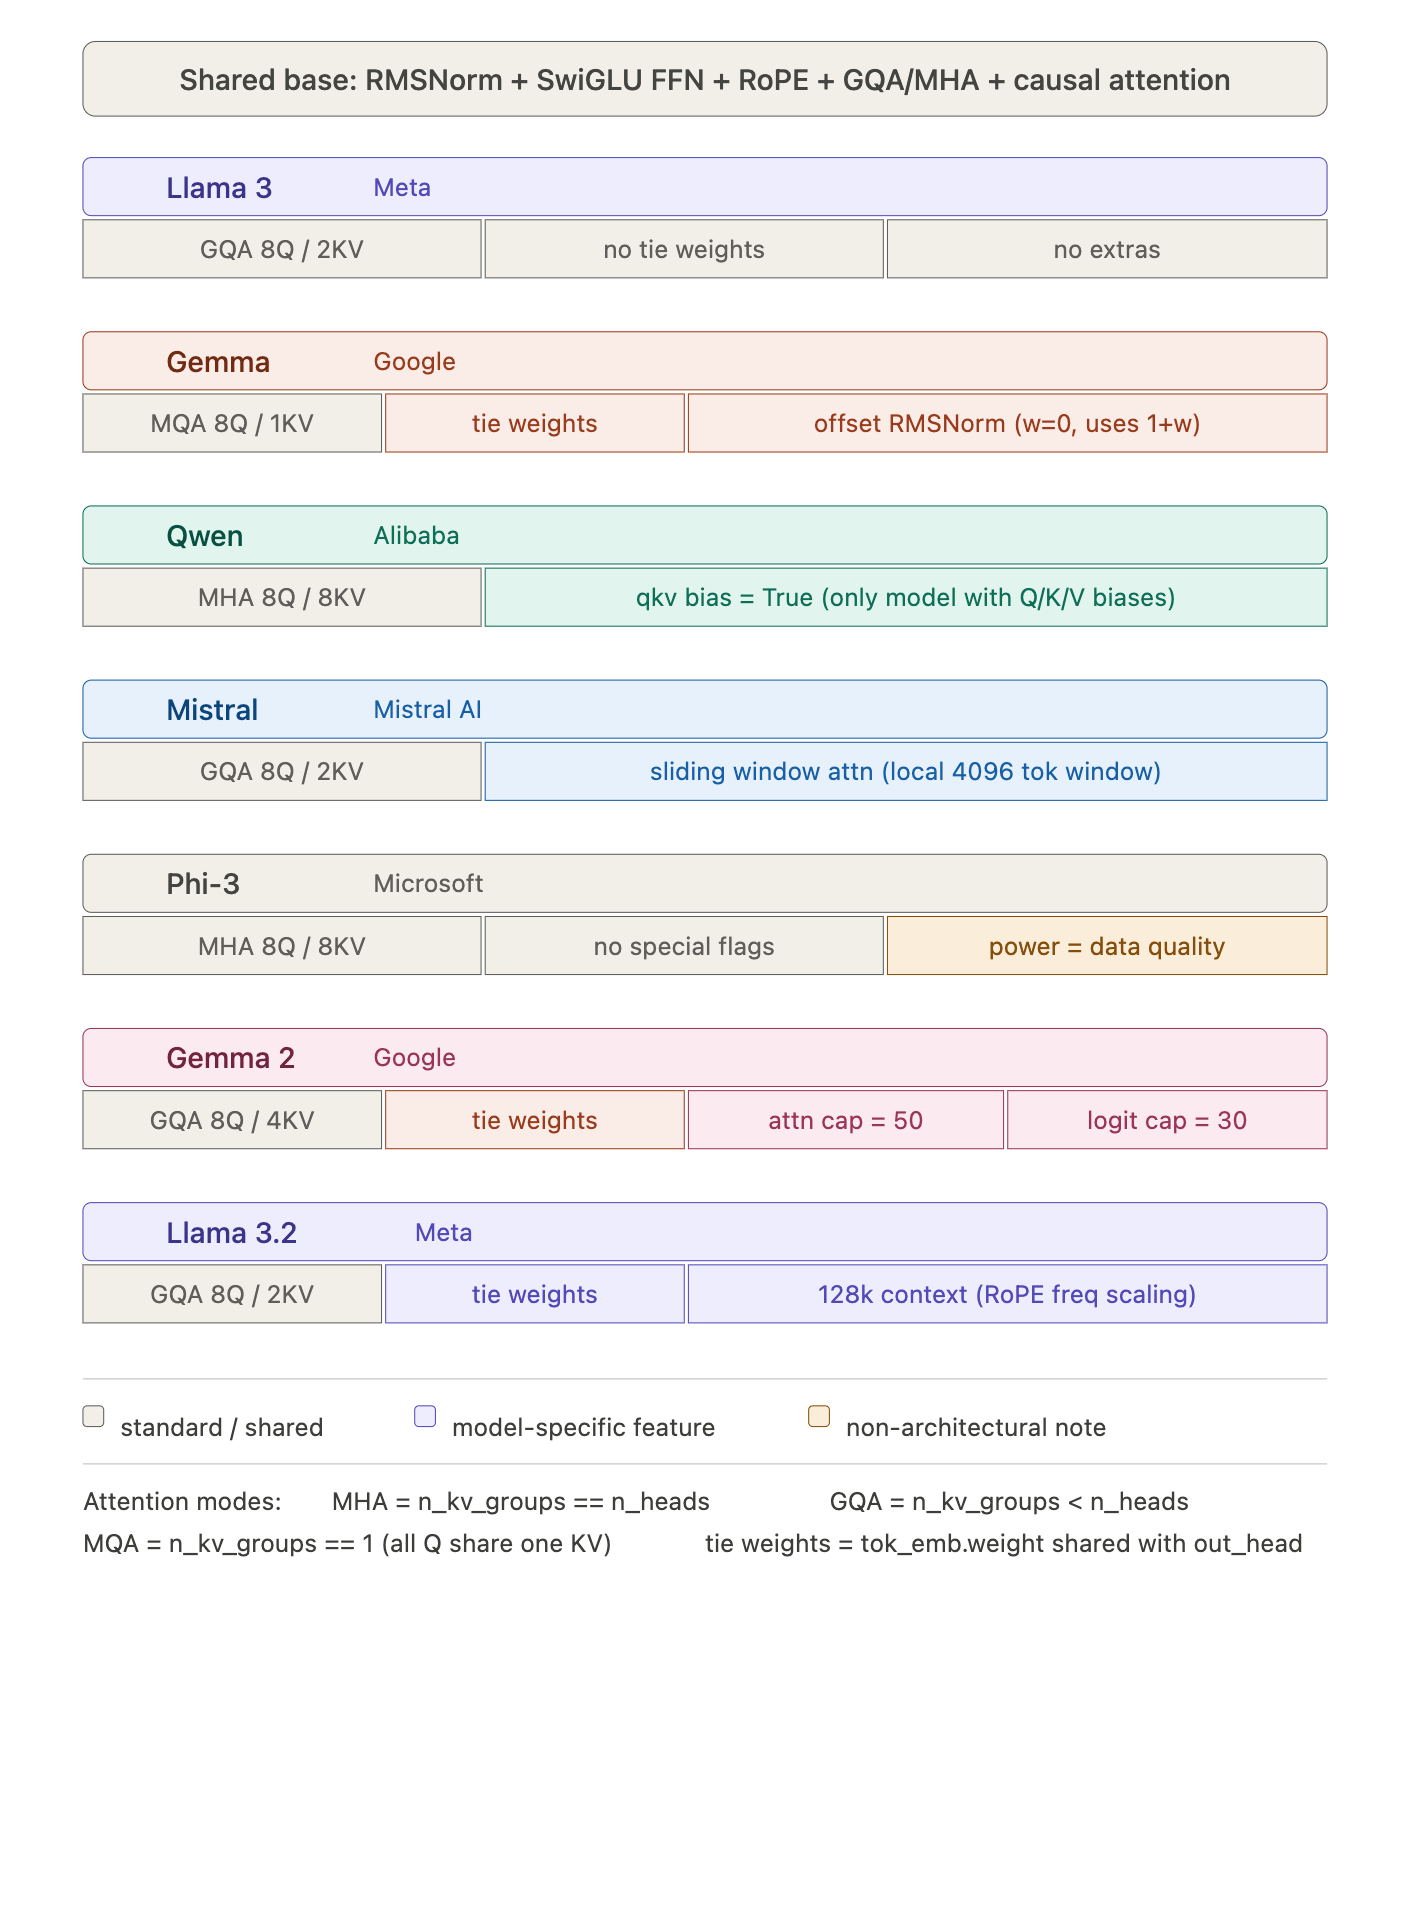

## The Core Idea
All 7 models use the same `UniversalLLM` class. The differences are just config flags. `emb_dim=256` and `n_layers=2` everywhere — scaled down for fast CPU smoke-testing. The flags are what matter.

---

## Config Flag Cheat Sheet

| Model | `n_kv_groups` | Unique flags | Key insight |
|---|---|---|---|
| **Llama 3** | 2 (GQA) | — | Baseline modern architecture, no extras |
| **Gemma** | 1 (MQA) | `is_gemma=True`, `tie_weights=True` | Most aggressive KV compression; offset RMSNorm |
| **Qwen** | 8 (MHA) | `qkv_bias=True` | Only model that adds bias to Q, K, V projections |
| **Mistral** | 2 (GQA) | `sliding_window_size=4096` | Attention capped to nearest 4096 tokens — O(window) not O(n²) |
| **Phi-3** | 8 (MHA) | — | Architecturally plain; performance comes from data quality alone |
| **Gemma 2** | 4 (GQA) | `attention_logit_cap=50.0`, `final_logit_cap=30.0` | tanh-clamps scores to prevent any token dominating |
| **Llama 3.2** | 2 (GQA) | `tie_weights=True`, `context_length=131072` | Ties weights to shrink size for mobile; 128k context via RoPE scaling |

---

## Key Concepts

**GQA / MQA / MHA** — all controlled by `n_kv_groups`:
- `n_kv_groups == n_heads` → MHA (standard, one KV head per Q head)
- `n_kv_groups < n_heads` → GQA (multiple Q heads share one KV head)
- `n_kv_groups == 1` → MQA (all Q heads share a single KV head — Gemma)

**`is_gemma`** → RMSNorm initialises weight to 0 and computes `(1 + weight)` instead of `weight` — neutral at init but different gradient flow.

**`tie_weights`** → `out_head.weight = tok_emb.weight`. One matrix serves as both input embedding and output projection. Saves parameters; used in Gemma, Llama 3.2, not Llama 3.

**`sliding_window_size`** (Mistral) → each token only attends to the nearest N tokens. Caps memory at O(window) vs O(seq²).

**`attention_logit_cap` / `final_logit_cap`** (Gemma 2) → `tanh(x / cap) * cap` applied to attention scores and output logits respectively. Prevents extreme values from destabilising training.

---

## Smoke Test Pattern
```python
model = UniversalLLM(cfg).to(device)
out = model(torch.randint(0, cfg["vocab_size"], (2, 64)).to(device))
# Expected output: (batch=2, seq_len=64, vocab_size)
```
Token IDs must stay within `[0, vocab_size)` — each model has a different vocab size so `test_input` is regenerated per config.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# =============================================================================
# RMNORM — Used in Llama, Mistral, Qwen, Phi-3
# =============================================================================

class RMSNorm(nn.Module):
    """
    Root Mean Square Normalization — a faster alternative to LayerNorm.

    LayerNorm does two things:
      1. Mean-centers the input  (subtracts mean)
      2. Scales by RMS           (divides by std)

    RMSNorm drops step 1 entirely. Empirically, the re-centering step
    contributes almost nothing to training stability, so removing it
    gives a ~15% speedup with no quality loss.

    Formula:
      RMSNorm(x) = x / RMS(x) * weight
      where RMS(x) = sqrt( mean(x²) + eps )

    Gemma variant:
      Initialises weight to 0 and adds 1 during forward, so the effective
      scale starts at 1.0 (neutral) but is learned from there.
      Standard RMSNorm initialises weight to 1.0 directly.
      Both are mathematically equivalent at init — just different conventions.
    """
    def __init__(self, dim, eps=1e-5, is_gemma=False):
        super().__init__()
        self.eps      = eps         # prevents division by zero when RMS ≈ 0
        self.is_gemma = is_gemma

        # Standard: weight starts at 1 → neutral scaling at init
        # Gemma:    weight starts at 0 → effective scale = (1 + 0) = 1 at init,
        #           but gradient flow differs slightly during early training
        self.weight = nn.Parameter(
            torch.zeros(dim) if is_gemma else torch.ones(dim)
        )

    def forward(self, x):
        # torch.rsqrt(y) = 1 / sqrt(y) — fused op, faster than separate sqrt + divide
        # x.pow(2).mean(-1, keepdim=True) = mean of squared values along last dim = RMS²
        norm_x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

        # Apply learned per-feature scale
        # Gemma:    multiply by (1 + weight) so zero-init weight → scale of 1
        # Standard: multiply by weight directly (already initialised to 1)
        return norm_x * (1 + self.weight) if self.is_gemma else norm_x * self.weight


# =============================================================================
# SwiGLU — Modern FFN used by Llama 3, Mistral, Qwen
# =============================================================================

class SwiGLU(nn.Module):
    """
    Swish-Gated Linear Unit — replaces the classic GPT-2 FFN (Linear → GELU → Linear).

    Classic FFN:
      output = W_down( GELU( W_up(x) ) )
      — one projection up, one activation, one projection down

    SwiGLU:
      output = W_down( SiLU(W_gate(x)) * W_up(x) )
      — two parallel projections up, element-wise multiplied, then projected down

    The key difference is the GATE stream (w1).
    Instead of just activating the up-projection, we compute a separate
    gating signal via SiLU and use it to *selectively suppress* values
    in the up-projection before the down-projection sees them.
    This acts like a learned, input-dependent filter — letting the network
    decide which information to pass through at each position.

    SiLU (Sigmoid Linear Unit) = x * sigmoid(x)
      Smooth, non-monotonic, and empirically outperforms GELU in this gated setting.

    No bias by default — consistent with Llama 3 / Mistral conventions.

    Three weight matrices (vs two in classic FFN):
      w1 — Gate    projection: d_in → hidden_dim
      w2 — Up      projection: d_in → hidden_dim
      w3 — Down    projection: hidden_dim → d_in
    """
    def __init__(self, d_in, hidden_dim, use_bias=False):
        super().__init__()
        self.w1 = nn.Linear(d_in,    hidden_dim, bias=use_bias)  # gate stream
        self.w2 = nn.Linear(d_in,    hidden_dim, bias=use_bias)  # up stream
        self.w3 = nn.Linear(hidden_dim, d_in,    bias=use_bias)  # down projection

    def forward(self, x):
        # 1. Gate:  SiLU( W_gate(x) )      — smooth, learned on/off signal
        # 2. Up:    W_up(x)                 — linear content projection
        # 3. Merge: gate * up               — gate suppresses irrelevant features
        # 4. Down:  W_down( gate * up )     — project back to model dimension
        gate   = F.silu(self.w1(x))  # (batch, seq_len, hidden_dim)
        up     = self.w2(x)          # (batch, seq_len, hidden_dim)
        return self.w3(gate * up)    # (batch, seq_len, d_in)

In [17]:
# =============================================================================
# ROTARY POSITIONAL EMBEDDING (RoPE)
# =============================================================================

def apply_rope(x):
    """
    Applies Rotary Positional Embedding to a query or key tensor.

    WHY RoPE over learned positional embeddings:
      Classic positional embeddings (like GPT-2's) ADD a position vector to
      the token embedding once at the input. RoPE instead ROTATES the query
      and key vectors inside every attention layer, encoding position directly
      into the attention score computation. This gives better length
      generalisation and is the standard in Llama, Mistral, Qwen, etc.

    CORE IDEA:
      Each pair of dimensions (x1, x2) in a head is treated as a 2D vector
      and rotated by an angle θ that depends on:
        - the token's position in the sequence
        - which dimension pair we're rotating (deeper dims rotate slower)
      Because both Q and K are rotated, their dot product naturally encodes
      the *relative* distance between two positions — the model learns to
      reason about "how far apart are these tokens" for free.

    ROTATION FORMULA (per dimension pair):
      [x1', x2'] = [x1·cos θ - x2·sin θ,
                    x1·sin θ + x2·cos θ]
      This is exactly a 2D rotation matrix applied element-wise.
    """
    b, n_heads, seq_len, head_dim = x.shape

    # inv_freq: one frequency per dimension PAIR → head_dim/2 values
    # Higher dimensions get smaller frequencies (rotate more slowly with position)
    # Shape: (head_dim/2,)
    inv_freq = 1.0 / (
        10000 ** (torch.arange(0, head_dim, 2).float() / head_dim)
    ).to(x.device)

    # t: position indices [0, 1, 2, ..., seq_len-1]
    t = torch.arange(seq_len, device=x.device).type_as(inv_freq)

    # Outer product → angle for every (position, dimension-pair) combination
    # Shape: (seq_len, head_dim/2)
    freqs = torch.outer(t, inv_freq)

    # Expand to (1, 1, seq_len, head_dim/2) so it broadcasts across batch + heads
    cos = torch.cos(freqs).unsqueeze(0).unsqueeze(0)
    sin = torch.sin(freqs).unsqueeze(0).unsqueeze(0)

    # Interleaved split: x1 = even indices (0,2,4,...), x2 = odd indices (1,3,5,...)
    # Each (x1[i], x2[i]) pair is the 2D vector we rotate by angle freqs[pos, i]
    x1 = x[..., 0::2]  # (b, n_heads, seq_len, head_dim/2)
    x2 = x[..., 1::2]  # (b, n_heads, seq_len, head_dim/2)

    rotated = torch.empty_like(x)
    rotated[..., 0::2] = x1 * cos - x2 * sin  # rotated even dims
    rotated[..., 1::2] = x1 * sin + x2 * cos  # rotated odd dims
    return rotated


# =============================================================================
# UNIVERSAL ATTENTION — supports MHA, GQA, and RoPE via config flags
# =============================================================================

class UniversalAttention(nn.Module):
    """
    A single attention class that handles three modes via config:

    1. MHA  (Multi-Head Attention)       — classic GPT-2 style
       n_kv_groups == n_heads → one K/V head per Q head

    2. GQA  (Grouped-Query Attention)    — used in Llama 3, Mistral, Qwen
       n_kv_groups < n_heads → multiple Q heads share one K/V head
       Reduces KV cache memory by (n_heads / n_kv_groups)×
       e.g. 32 Q heads, 8 KV groups → 4 Q heads share each K/V

    3. MQA  (Multi-Query Attention)      — extreme GQA
       n_kv_groups == 1 → ALL Q heads share a single K/V head

    RoPE is applied to Q and K (not V) when use_rope=True.
    """
    def __init__(self, cfg):
        super().__init__()
        self.num_heads     = cfg["n_heads"]
        # Default to MHA (n_kv_groups == n_heads) if not specified
        self.num_kv_groups = cfg.get("n_kv_groups", self.num_heads)
        self.head_dim      = cfg["emb_dim"] // self.num_heads

        # Q always projects to full emb_dim (one head per query)
        self.W_query = nn.Linear(
            cfg["emb_dim"], cfg["emb_dim"],
            bias=cfg.get("qkv_bias", False)
        )
        # K and V project to (n_kv_groups × head_dim) — smaller than Q in GQA/MQA
        # In MHA this equals emb_dim; in GQA it's a fraction of it
        self.W_key = nn.Linear(
            cfg["emb_dim"], self.num_kv_groups * self.head_dim,
            bias=cfg.get("qkv_bias", False)
        )
        self.W_value = nn.Linear(
            cfg["emb_dim"], self.num_kv_groups * self.head_dim,
            bias=cfg.get("qkv_bias", False)
        )
        self.out_proj = nn.Linear(
            cfg["emb_dim"], cfg["emb_dim"],
            bias=cfg.get("out_bias", False)
        )
        self.use_rope = cfg.get("use_rope", True)

    def forward(self, x):
        b, seq_len, _ = x.shape

        # Project and reshape into per-head views
        # Q: (b, n_heads,     seq_len, head_dim)
        # K: (b, n_kv_groups, seq_len, head_dim)  ← fewer heads than Q in GQA
        # V: (b, n_kv_groups, seq_len, head_dim)
        q = self.W_query(x).view(b, seq_len, self.num_heads,     self.head_dim).transpose(1, 2)
        k = self.W_key(x)  .view(b, seq_len, self.num_kv_groups, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, seq_len, self.num_kv_groups, self.head_dim).transpose(1, 2)

        # Apply RoPE to Q and K (not V — only the vectors used in dot-product
        # scoring need position information)
        if self.use_rope:
            q = apply_rope(q)
            k = apply_rope(k)

        # --- GQA expansion ---
        # scaled_dot_product_attention requires Q and K/V to have the same
        # number of heads. In GQA, we tile each KV head `group_size` times
        # so it aligns with the Q heads that share it.
        # repeat_interleave repeats each element in-place:
        #   [kv0, kv1] with group_size=4 → [kv0, kv0, kv0, kv0, kv1, kv1, kv1, kv1]
        # This is memory-efficient in practice (with KV cache), but here it
        # materialises the full expanded tensor.
        group_size = self.num_heads // self.num_kv_groups
        if group_size > 1:  # skip expansion entirely for standard MHA
            k = k.repeat_interleave(group_size, dim=1)  # dim=1 = heads dimension
            v = v.repeat_interleave(group_size, dim=1)

        # Flash Attention with causal mask (each token only attends left)
        # Output: (b, n_heads, seq_len, head_dim)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        # Merge heads: (b, n_heads, seq_len, head_dim) → (b, seq_len, emb_dim)
        # then project back to model dimension
        return self.out_proj(
            attn.transpose(1, 2).contiguous().view(b, seq_len, -1)
        )

In [19]:
# =============================================================================
# UNIVERSAL TRANSFORMER BLOCK
# =============================================================================

class UniversalBlock(nn.Module):
    """
    One transformer block — the unit that gets stacked N times to form the LLM.

    Combines all the modern components defined earlier:
      - UniversalAttention  (MHA or GQA, with optional RoPE)
      - SwiGLU              (gated FFN)
      - RMSNorm             (faster alternative to LayerNorm)

    Uses Pre-LN (normalize BEFORE each sub-layer), which is more training-stable
    than the original Post-LN design. Residual connections on both sub-layers
    let gradients flow directly to early layers (solves vanishing gradients).

    Architecture per block:
      x = x + Attention( RMSNorm(x) )   ← attention sub-layer
      x = x + SwiGLU(   RMSNorm(x) )   ← FFN sub-layer
    """
    def __init__(self, cfg):
        super().__init__()
        self.att   = UniversalAttention(cfg)
        self.ff    = SwiGLU(
                         cfg["emb_dim"],
                         cfg.get("hidden_dim", 4 * cfg["emb_dim"]),  # default 4× expansion
                         use_bias=cfg.get("ff_bias", False)
                     )
        # Two separate norms — one before attention, one before FFN
        # is_gemma flag switches to Gemma's 0-init weight convention
        self.norm1 = RMSNorm(cfg["emb_dim"], is_gemma=cfg.get("is_gemma", False))
        self.norm2 = RMSNorm(cfg["emb_dim"], is_gemma=cfg.get("is_gemma", False))

    def forward(self, x):
        # Pre-LN residual pattern: normalize input first, then add result back
        x = x + self.att(self.norm1(x))  # attention sub-layer
        x = x + self.ff (self.norm2(x))  # FFN sub-layer
        return x


# =============================================================================
# UNIVERSAL LLM — full model assembling all components
# =============================================================================

class UniversalLLM(nn.Module):
    """
    Complete decoder-only LLM. Configurable enough to replicate the core
    architecture of Llama 3, Mistral, Gemma, Qwen, or plain GPT-2 style
    models by changing the config dict.

    Key config flags and what they control:
      use_rope      → True  = RoPE positional encoding (no pos_emb table)
                      False = learned absolute positional embeddings (GPT-2 style)
      is_gemma      → passes through to RMSNorm for Gemma's 0-init convention
      tie_weights   → shares the token embedding matrix with the output head
                      (Gemma does this; Llama 3 does not — see below)
      n_kv_groups   → sets GQA (< n_heads) or MHA (== n_heads) in attention
      hidden_dim    → FFN expansion size (default 4× emb_dim)
    """
    def __init__(self, cfg):
        super().__init__()

        # Token embedding: maps integer token IDs → dense vectors
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding: only used when RoPE is OFF.
        # RoPE encodes position inside every attention layer, so a separate
        # positional embedding table would be redundant and is set to None.
        self.pos_emb = (
            nn.Embedding(cfg["context_length"], cfg["emb_dim"])
            if not cfg.get("use_rope", True)
            else None
        )

        # Stack of N identical transformer blocks
        self.blocks     = nn.ModuleList([UniversalBlock(cfg) for _ in range(cfg["n_layers"])])

        # Final norm applied once after all blocks, before the output projection
        self.final_norm = RMSNorm(cfg["emb_dim"], is_gemma=cfg.get("is_gemma", False))

        # Output head: projects hidden states → vocab logits (no bias — standard)
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

        # Weight tying: makes out_head.weight point to the SAME tensor as tok_emb.weight
        # Intuition: the input embedding and output projection are inverse operations
        # (token → vector vs vector → token), so sharing weights saves parameters
        # and often improves performance on smaller models.
        # Used in Gemma; NOT used in Llama 3 (they keep them separate).
        if cfg.get("tie_weights", False):
            self.out_head.weight = self.tok_emb.weight

    def forward(self, in_idx):
        # in_idx: (batch, seq_len) integer token IDs
        x = self.tok_emb(in_idx)  # → (batch, seq_len, emb_dim)

        # Add absolute positional encoding if RoPE is disabled
        if self.pos_emb is not None:
            positions = torch.arange(in_idx.shape[1], device=in_idx.device)
            x = x + self.pos_emb(positions)

        # Pass through all transformer blocks sequentially
        for block in self.blocks:
            x = block(x)

        # Final norm → output projection → logits over vocabulary
        # Shape: (batch, seq_len, vocab_size)
        return self.out_head(self.final_norm(x))

In [20]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ==========================================================================
    # MODEL CONFIGURATIONS
    # Each config is passed directly into UniversalLLM(cfg).
    # emb_dim=256 and n_layers=2 everywhere — scaled down from real sizes
    # so all 7 models run quickly on CPU for shape verification.
    # The architectural FLAGS are what matter here, not the size numbers.
    # ==========================================================================

    # --- 1. Llama 3 ---
    # The baseline modern architecture: GQA + RoPE + RMSNorm + SwiGLU, no frills.
    # n_kv_groups=2 with n_heads=8 → 4 Q heads share each KV head (saves KV cache memory)
    llama3_cfg = {
        "vocab_size": 128256, "context_length": 8192,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 2,       # GQA: 8 Q heads / 2 KV groups = 4 Q per KV
        "use_rope": True,
        "is_gemma": False,
        "qkv_bias": False,
        "tie_weights": False    # Llama 3 keeps embedding and output head separate
    }

    # --- 2. Gemma ---
    # Google's Gemma. Three differences from Llama 3:
    #   - n_kv_groups=1 → extreme MQA (all Q heads share ONE KV head)
    #   - is_gemma=True → RMSNorm uses 0-init weights with (1 + weight) offset
    #   - tie_weights=True → tok_emb and out_head share the same weight matrix
    gemma_cfg = {
        "vocab_size": 256000, "context_length": 8192,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 1,       # MQA: most aggressive KV compression possible
        "use_rope": True,
        "is_gemma": True,       # enables offset RMSNorm (Gemma-specific)
        "qkv_bias": False,
        "tie_weights": True     # input embedding == output projection (saves params)
    }

    # --- 3. Qwen ---
    # Alibaba's Qwen. Architecturally close to standard MHA.
    # The one standout flag: qkv_bias=True — Qwen adds bias terms to Q, K, V
    # projections, which most modern models drop for efficiency.
    qwen_cfg = {
        "vocab_size": 151936, "context_length": 4096,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 8,       # n_kv_groups == n_heads → standard MHA
        "use_rope": True,
        "is_gemma": False,
        "qkv_bias": True,       # Qwen's distinguishing flag — biases in QKV
        "tie_weights": False
    }

    # --- 4. Mistral ---
    # Introduced Sliding Window Attention (SWA) to the mainstream.
    # Instead of attending to the full sequence, each token only attends
    # to the nearest `sliding_window_size` tokens. This caps attention
    # memory at O(window) instead of O(seq_len²), enabling very long contexts
    # without proportional memory growth.
    # Note: UniversalLLM stores this flag but SWA isn't wired into
    # UniversalAttention here — it's noted as the key architectural delta.
    mistral_cfg = {
        "vocab_size": 32000, "context_length": 8192,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 2,
        "use_rope": True,
        "is_gemma": False,
        "qkv_bias": False,
        "tie_weights": False,
        "sliding_window_size": 4096  # the defining Mistral feature
    }

    # --- 5. Phi-3 ---
    # Microsoft's small but capable model. Architecturally unremarkable —
    # standard MHA (n_kv_groups == n_heads), no special flags.
    # Its strength comes entirely from data quality ("textbook-quality" curation),
    # not structural innovations. A reminder that data > architecture.
    phi3_cfg = {
        "vocab_size": 32064, "context_length": 4096,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 8,       # standard MHA — nothing unusual here
        "use_rope": True,
        "is_gemma": False,
        "qkv_bias": False,
        "tie_weights": False
    }

    # --- 6. Gemma 2 ---
    # Adds two Gemma-2-specific techniques on top of base Gemma:
    #   - attention_logit_cap: tanh-clamps attention scores to ±50
    #     before softmax, preventing any single token from dominating
    #   - final_logit_cap: tanh-clamps output logits to ±30
    #     before the loss, stabilising training on extreme predictions
    # Also alternates between Sliding Window and Global Attention per layer
    # (not implemented in UniversalLLM, noted as architectural context).
    gemma2_cfg = {
        "vocab_size": 256000, "context_length": 8192,
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 4,
        "use_rope": True,
        "is_gemma": True,
        "qkv_bias": False,
        "tie_weights": True,
        "attention_logit_cap": 50.0,  # clamp attn scores: tanh(x/50)*50
        "final_logit_cap":     30.0   # clamp output logits: tanh(x/30)*30
    }

    # --- 7. Llama 3.2 ---
    # Meta's mobile-optimised variant of Llama 3.
    # Two changes from Llama 3:
    #   - tie_weights=True: reverts to GPT-2's weight tying trick to shrink
    #     model size for on-device (1B / 3B) deployment
    #   - context_length=131072: uses advanced RoPE frequency scaling
    #     to handle 128k token context windows
    llama3_2_cfg = {
        "vocab_size": 128256, "context_length": 131072,  # 128k context
        "emb_dim": 256, "n_layers": 2, "n_heads": 8,
        "n_kv_groups": 2,
        "use_rope": True,
        "is_gemma": False,
        "qkv_bias": False,
        "tie_weights": True   # tied weights → smaller model for mobile
    }

    # ==========================================================================
    # SMOKE TEST — build each model, run a forward pass, print output shape
    # ==========================================================================
    models = {
        "Llama 3":   llama3_cfg,
        "Gemma":     gemma_cfg,
        "Qwen":      qwen_cfg,
        "Mistral":   mistral_cfg,
        "Phi-3":     phi3_cfg,
        "Gemma 2":   gemma2_cfg,
        "Llama 3.2": llama3_2_cfg,
    }

    print("--- Testing Modern Architectures ---")
    for name, cfg in models.items():
        print(f"\nBuilding {name}...")
        model = UniversalLLM(cfg).to(device)

        # Token IDs must be within [0, vocab_size) — each model has a different vocab
        test_input = torch.randint(0, cfg["vocab_size"], (2, 64)).to(device)

        out = model(test_input)
        # Expected: (batch=2, seq_len=64, vocab_size) — logits over full vocabulary
        print(f"Output shape: {out.shape}")
        # numel() counts total scalar values across all parameter tensors
        print(f"Parameters:  {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

--- Testing Modern Architectures ---

Building Llama 3 (Bonus 07)...
Success! Output Logits Shape: torch.Size([2, 64, 128256])
Total Parameters: 67.57M

Building Gemma (Bonus 12)...
Success! Output Logits Shape: torch.Size([2, 64, 256000])
Total Parameters: 67.41M

Building Qwen (Bonus 11)...
Success! Output Logits Shape: torch.Size([2, 64, 151936])
Total Parameters: 79.89M

Building Mistral (Bonus 13)...
Success! Output Logits Shape: torch.Size([2, 64, 32000])
Total Parameters: 18.29M

Building Phi-3 (Bonus 14)...
Success! Output Logits Shape: torch.Size([2, 64, 32064])
Total Parameters: 18.52M

Building Gemma 2 (Bonus 15)...
Success! Output Logits Shape: torch.Size([2, 64, 256000])
Total Parameters: 67.50M

Building Llama 3.2 (Bonus 16)...
Success! Output Logits Shape: torch.Size([2, 64, 128256])
Total Parameters: 34.74M
